# Text into Numbers

**What are tokens?**

* Why and how text is transformed into numbers
* Key terms including token, embedding, and subword
* Why embeddings are more efficient then tokens
* Why tokenization is difficult, and why different tokenizers are different

Token: A piece of text that can be represented as an integer

* Character Token - H     - 39 E - 68, L - 75, L - 75, O - 78
* Subword Token   - He    - 1544 llo - 18798
* Word Token      - Hello - 15496

"Token" is a piece of text; the corresponding number is called "token ID" or "token index".

* He - Token
* 1544 - Token index

**Why not just use characters as tokens?**

* 1 $\rightarrow$ a
* 2 $\rightarrow$ b
* 26 $\rightarrow$ z
* 31 $\rightarrow$ 4
* 191 $\rightarrow$ $

* Problem 1: >150 k characters, which increases over time
* Problem 2: Ignores statistical regularities in language
* Problem 3: Requires a lot of additional memory, which limits the context window

So if a model has a context window of 1000 tokens, and if each token is a character, then a thousand tokens is maybe around 200 words, which is basically just one paragraph.

In tontrast, a subword or word based tokenization system would mean that a thousand tokens is maybe 800 words, which is, let's say, four times as much information in the text that the language model.

* ***TEXT IS CONVERTED INTO TOKENS, BUT LLMs WORK WITH EMBEDDINGS***
* ***Tokens must be converted into embeddings before the LLM***
* LLMs modify the embeddings for classification and generation

$$ Text \rightarrow Token\,IDs \rightarrow Embeddings \rightarrow Unembeddings \rightarrow Tokens \rightarrow Text $$

Main algorithm which is Attention mechanism is applied to Embeddings to get Unembeddings.

**What is Embedding?**

* Embedding: a dense numeric representation of a token
* Advantages over integers: more text can be represented using fewer numbers. Semantic relations across tokens can be represented.

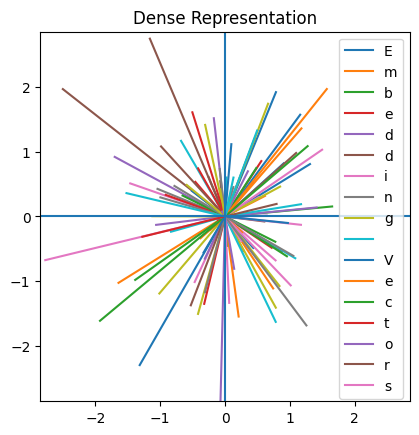

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_words = 100
embeddings = np.random.randn(n_words, 2)

for x, y in embeddings:
    plt.plot([0, x], [0, y])

# wycentrowanie
max_val = np.abs(embeddings).max()
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.axhline(0)
plt.axvline(0)
plt.title('Dense Representation')
plt.legend('Embedding Vectors')
plt.show()

Each word gets a vector, the closer 2 vectors are the closer meaning they have. In real life real embeddings are

* high dimensional (768-D)
* not human-interpretable
* **modified dynamically during model calculations**

**Challenges of tokenization**

* Fewer tokens means less memory and improved generalization, but is less efficient and effective
* More tokens means more training, but can increase text compression and convey more information
* Statistical dependencies change across languages - and databases within a language
* Tokenization must be learned from text, and different texts will create different tokenizations
* Different tokenizers optimize different criteria (e.g., GPT vs BERT)

**Implications of challenges**

* Tokenization is statistical and can be done in many ways, and it requires several decisions, parameter choices, and assumptions
* Embeddings require even more steps and choices
* Tokenization and embeddings are based on training data; different training datasets will give different protocols
* And all of this happens before the LLM even sees the data

# Parsing text to numbered tokens

* How to create a vocabulary from words in a text
* What encoder and decoder functions are, and how to create them in Python
* An intruduction to word-based tokenization

## Vocabulary

* Vocabulary - (a.k.a. lexicon) A unique set of tokens in a tokenizer. Vocabulary items can be a characters, subwords, words, numbers, code segments, emojis, etc.
* Encoder - a function that maps text into integers
* Decoder - a function (look-up-table) that maps integers into text

Encoders and decoders are inverse

## Goal

* Split a sentence into lower-case words
* Create a vocab from unique words (tokens)
* Create encoder and decoder functions (as dictionaries)
* Create a tokenization scheme

## Intro

In [ ]:
text = ['All that we are is the result of what we have thought',
        'To be or not to be that is the question',
        'Be yourself everyone else is already taken']
text

['All that we are is the result of what we have thought',
 'To be or not to be that is the question',
 'Be yourself everyone else is already taken']

separate into words by splitting by spaces

In [ ]:
import re
re.split('\s', text[0])

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3862492671.py:2: SyntaxWarning: invalid escape sequence '\s'
  re.split('\s', text[0])


['All',
 'that',
 'we',
 'are',
 'is',
 'the',
 'result',
 'of',
 'what',
 'we',
 'have',
 'thought']

recombine

In [ ]:
' '.join(re.split('\s',text[0]))

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3874999201.py:1: SyntaxWarning: invalid escape sequence '\s'
  ' '.join(re.split('\s',text[0]))


'All that we are is the result of what we have thought'

In [ ]:
all_words = re.split('\s',' '.join(text).lower())
all_words

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2422107524.py:1: SyntaxWarning: invalid escape sequence '\s'
  all_words = re.split('\s',' '.join(text).lower())


['all',
 'that',
 'we',
 'are',
 'is',
 'the',
 'result',
 'of',
 'what',
 'we',
 'have',
 'thought',
 'to',
 'be',
 'or',
 'not',
 'to',
 'be',
 'that',
 'is',
 'the',
 'question',
 'be',
 'yourself',
 'everyone',
 'else',
 'is',
 'already',
 'taken']

## Lexicon (vocab)

In [ ]:
import re

text = ['All that we are is the result of what we have thought',
        'To be or not to be that is the question',
        'Be yourself everyone else is already taken']
text

['All that we are is the result of what we have thought',
 'To be or not to be that is the question',
 'Be yourself everyone else is already taken']

In [ ]:
all_words = re.split('\s',' '.join(text).lower())
vocab = sorted(set(all_words))
vocab

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2922539992.py:1: SyntaxWarning: invalid escape sequence '\s'
  all_words = re.split('\s',' '.join(text).lower())


['all',
 'already',
 'are',
 'be',
 'else',
 'everyone',
 'have',
 'is',
 'not',
 'of',
 'or',
 'question',
 'result',
 'taken',
 'that',
 'the',
 'thought',
 'to',
 'we',
 'what',
 'yourself']

In [ ]:
print(f'There are {len(vocab)} unique words in our lexicon.')

There are 21 unique words in our lexicon.


## Encoder

In [ ]:
word_2_idx = {}

for i, word in enumerate(vocab):
  word_2_idx[word] = i

word_2_idx

{'all': 0,
 'already': 1,
 'are': 2,
 'be': 3,
 'else': 4,
 'everyone': 5,
 'have': 6,
 'is': 7,
 'not': 8,
 'of': 9,
 'or': 10,
 'question': 11,
 'result': 12,
 'taken': 13,
 'that': 14,
 'the': 15,
 'thought': 16,
 'to': 17,
 'we': 18,
 'what': 19,
 'yourself': 20}

## Decoder

In [ ]:
idx_2_word = {}

for i, word in enumerate(vocab):
  idx_2_word[i] = word

idx_2_word

{0: 'all',
 1: 'already',
 2: 'are',
 3: 'be',
 4: 'else',
 5: 'everyone',
 6: 'have',
 7: 'is',
 8: 'not',
 9: 'of',
 10: 'or',
 11: 'question',
 12: 'result',
 13: 'taken',
 14: 'that',
 15: 'the',
 16: 'thought',
 17: 'to',
 18: 'we',
 19: 'what',
 20: 'yourself'}

In [ ]:
print(f'The word "to" has index {word_2_idx['to']}')

The word "to" has index 17


In [ ]:
print(f'The index "7" maps to the word {idx_2_word[7]}')

The index "7" maps to the word is


## Select random words from dictionary

In [ ]:
import numpy as np

random_idx   = np.random.randint(0, len(vocab), size = 10)
random_words = [idx_2_word[i] for i in random_idx]
' '.join(random_words)

'already everyone yourself is question of not is all or'

## Tokens

In [ ]:
text_as_int = [word_2_idx[i] for i in all_words]
text_as_int

[0,
 14,
 18,
 2,
 7,
 15,
 12,
 9,
 19,
 18,
 6,
 16,
 17,
 3,
 10,
 8,
 17,
 3,
 14,
 7,
 15,
 11,
 3,
 20,
 5,
 4,
 7,
 1,
 13]

In [ ]:
for token in text_as_int:
  print(f'Token {token:2}: {idx_2_word[token]}')

Token  0: all
Token 14: that
Token 18: we
Token  2: are
Token  7: is
Token 15: the
Token 12: result
Token  9: of
Token 19: what
Token 18: we
Token  6: have
Token 16: thought
Token 17: to
Token  3: be
Token 10: or
Token  8: not
Token 17: to
Token  3: be
Token 14: that
Token  7: is
Token 15: the
Token 11: question
Token  3: be
Token 20: yourself
Token  5: everyone
Token  4: else
Token  7: is
Token  1: already
Token 13: taken


## Encoder

In [ ]:
text = ['All that we are is the result of what we have thought',
        'To be or not to be that is the question',
        'Be yourself everyone else is already taken']
text

['All that we are is the result of what we have thought',
 'To be or not to be that is the question',
 'Be yourself everyone else is already taken']

In [ ]:
all_words = re.split('\s',' '.join(text).lower())
vocab = sorted(set(all_words))
word_2_idx = {word: i for i, word in enumerate(vocab)}
idx_2_word = {i: word for i, word in enumerate(vocab)}

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1904075808.py:1: SyntaxWarning: invalid escape sequence '\s'
  all_words = re.split('\s',' '.join(text).lower())


In [ ]:
def encoder(text):
  words = re.split('\s', text.lower())
  vector = [word_2_idx[w] for w in words]
  return vector

idxs = encoder("what we have thought is not what else question")
idxs

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2126091148.py:2: SyntaxWarning: invalid escape sequence '\s'
  words = re.split('\s', text.lower())


[19, 18, 6, 16, 7, 8, 19, 4, 11]

## Decoder

In [ ]:
def decoder(idxs):
  vector = [idx_2_word[i] for i in idxs]
  words = ' '.join(vector)
  return words

words = decoder(idxs)
words

'what we have thought is not what else question'

In [ ]:
decoder(encoder('all be yourself'))

'all be yourself'

## Visualize Tokens

In [ ]:
len(words)

46

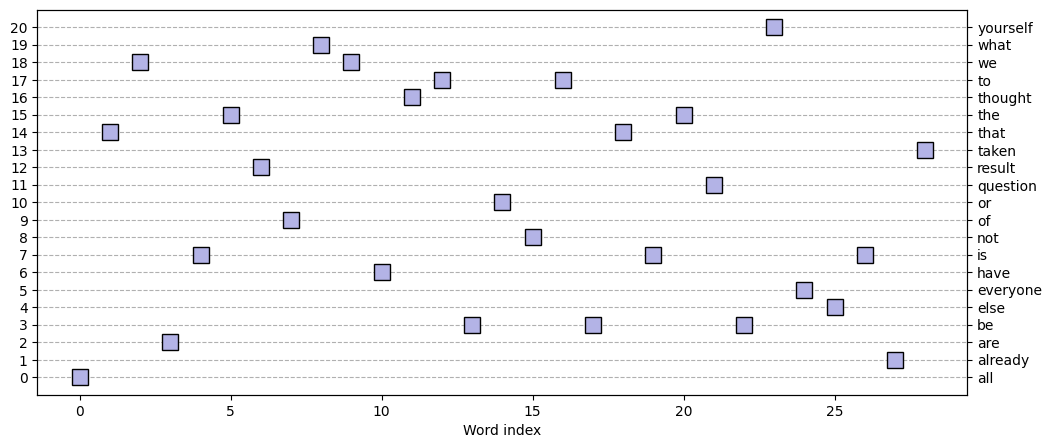

In [ ]:
import matplotlib.pyplot as plt

all_text = ' '.join(text)
tokens = encoder(all_text)

_, ax = plt.subplots(1, figsize = (12, 5))

ax.plot(tokens, 'ks', markersize = 12, markerfacecolor = [.7,.7,.9])
ax.set(xlabel='Word index', yticks = range(len(vocab)))
ax.grid(linestyle = '--', axis = 'y')

ax2 = ax.twinx()
ax2.plot(tokens, alpha = 0)
ax2.set(yticks=range(len(vocab)), yticklabels = vocab)

plt.show()

## Context

In [ ]:
target_word = 'to'
target_idx = word_2_idx[target_word]

target_locs= np.where(np.array(all_words) == target_word)[0]

for t in target_locs:
  print(tokens[t-1:t+2])
  print(' '.join(all_words[t-1:t+2]),'\n')

[16, 17, 3]
thought to be 

[8, 17, 3]
not to be 



## One hot encoding

In [ ]:
import pandas as pd
one_hot = np.array(np.array(pd.get_dummies(all_words).T), dtype = int)
print(one_hot)

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
# invert to display better
one_hot = one_hot == 0

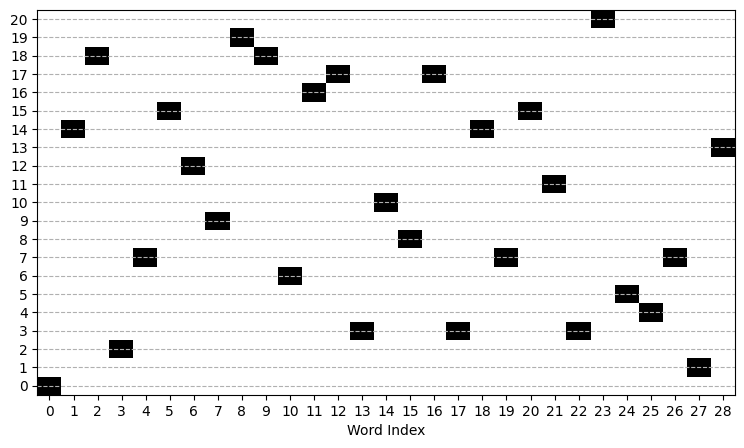

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (9,5))

one_hot = np.array(pd.get_dummies(all_words, dtype = int).T) == 0
plt.imshow(one_hot, cmap = 'gray', origin = 'lower', aspect = 'auto')
ax.set(xlabel = 'Word Index', yticks = range(len(vocab)), xticks = range(len(all_words)))
ax.grid(linestyle = '--', axis = 'y')
plt.show()

# Preparing text for tokenization


* How to import text from the web
* An introduction to regexp to remove "weird" characters from text
* How to parse text into words based on puctuation and whitespace
* More about encoder and decoder function

## Get Text

In [ ]:
import numpy as np
import requests
import re

In [ ]:
book = requests.get('https://www.gutenberg.org/files/35/35-0.txt')

text = book.text
print(type(text))
print(len(text))
print(text[:2000])

<class 'str'>
182973
*** START OF THE PROJECT GUTENBERG EBOOK 35 ***




The Time Machine

An Invention

by H. G. Wells


CONTENTS

 I Introduction
 II The Machine
 III The Time Traveller Returns
 IV Time Travelling
 V In the Golden Age
 VI The Sunset of Mankind
 VII A Sudden Shock
 VIII Explanation
 IX The Morlocks
 X When Night Came
 XI The Palace of Green Porcelain
 XII In the Darkness
 XIII The Trap of the White Sphinx
 XIV The Further Vision
 XV The Time Traveller’s Return
 XVI After the Story
 Epilogue




 I.
 Introduction


The Time Traveller (for so it will be convenient to speak of him) was
expounding a recondite matter to us. His pale grey eyes shone and
twinkled, and his usually pale face was flushed and animated. The fire
burnt brightly, and the soft radiance of the incandescent lights in the
lilies of silver caught the bubbles that flashed and passed in our
glasses. Our chairs, being his patents, embraced and caressed us rather
than submitted to be sat upon, and there was

In [ ]:
text[:2000]

'*** START OF THE PROJECT GUTENBERG EBOOK 35 ***\r\n\r\n\r\n\r\n\r\nThe Time Machine\r\n\r\nAn Invention\r\n\r\nby H. G. Wells\r\n\r\n\r\nCONTENTS\r\n\r\n I Introduction\r\n II The Machine\r\n III The Time Traveller Returns\r\n IV Time Travelling\r\n V In the Golden Age\r\n VI The Sunset of Mankind\r\n VII A Sudden Shock\r\n VIII Explanation\r\n IX The Morlocks\r\n X When Night Came\r\n XI The Palace of Green Porcelain\r\n XII In the Darkness\r\n XIII The Trap of the White Sphinx\r\n XIV The Further Vision\r\n XV The Time Traveller’s Return\r\n XVI After the Story\r\n Epilogue\r\n\r\n\r\n\r\n\r\n I.\r\n Introduction\r\n\r\n\r\nThe Time Traveller (for so it will be convenient to speak of him) was\r\nexpounding a recondite matter to us. His pale grey eyes shone and\r\ntwinkled, and his usually pale face was flushed and animated. The fire\r\nburnt brightly, and the soft radiance of the incandescent lights in the\r\nlilies of silver caught the bubbles that flashed and passed in our\r\nglas

## Characters to Replace with Space

In [ ]:
import re

strings_2_replace = [
    '\s+',   # all weird shit
]

for str_2_match in strings_2_replace:
  regexp = re.compile(r'%s'%str_2_match)
  text = regexp.sub(' ', text)

# remove non-ASCII characters
text = re.sub(r'[^\x00-\x7F]+', ' ', text)

# remove numbers
text = re.sub('\d+', '', text)

# and make everything lower-case
text = text.lower()
text

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-161037072.py:4: SyntaxWarning: invalid escape sequence '\s'
  '\s+',   # all weird shit
/tmp/ipython-input-161037072.py:15: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+', '', text)


'*** start of the project gutenberg ebook  *** the time machine an invention by h. g. wells contents i introduction ii the machine iii the time traveller returns iv time travelling v in the golden age vi the sunset of mankind vii a sudden shock viii explanation ix the morlocks x when night came xi the palace of green porcelain xii in the darkness xiii the trap of the white sphinx xiv the further vision xv the time traveller s return xvi after the story epilogue i. introduction the time traveller (for so it will be convenient to speak of him) was expounding a recondite matter to us. his pale grey eyes shone and twinkled, and his usually pale face was flushed and animated. the fire burnt brightly, and the soft radiance of the incandescent lights in the lilies of silver caught the bubbles that flashed and passed in our glasses. our chairs, being his patents, embraced and caressed us rather than submitted to be sat upon, and there was that luxurious after-dinner atmosphere, when thought ru

## Parse text into words

In [ ]:
# split by punctuation
import string
print(string.punctuation)

puncts_re = f'[{string.punctuation}\s]+' # add white space

words = re.split(puncts_re,text)
words = [item.strip() for item in words if item.strip()]

# remove single-character words
words = [item for item in words if len(item)>1]

words[:50]

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3511293540.py:5: SyntaxWarning: invalid escape sequence '\s'
  puncts_re = f'[{string.punctuation}\s]+' # add white space


['start',
 'of',
 'the',
 'project',
 'gutenberg',
 'ebook',
 'the',
 'time',
 'machine',
 'an',
 'invention',
 'by',
 'wells',
 'contents',
 'introduction',
 'ii',
 'the',
 'machine',
 'iii',
 'the',
 'time',
 'traveller',
 'returns',
 'iv',
 'time',
 'travelling',
 'in',
 'the',
 'golden',
 'age',
 'vi',
 'the',
 'sunset',
 'of',
 'mankind',
 'vii',
 'sudden',
 'shock',
 'viii',
 'explanation',
 'ix',
 'the',
 'morlocks',
 'when',
 'night',
 'came',
 'xi',
 'the',
 'palace',
 'of']

## Vocab

In [ ]:
# create the vocab (set of unique words)
vocab = sorted(set(words))

# convenience variables
n_words = len(words)
n_lex = len(vocab)

print(f'{n_words} words')
print(f' {n_lex} unique tokens')

30698 words
 4589 unique tokens


## Encoder/Decoder

Create token dictionaries and encoder/decoder functions

In [ ]:
word_2_idx = {w:i for i,w in enumerate(vocab)}
idx_2_word = {i:w for i,w in enumerate(vocab)}

# print out a few
for i in list(word_2_idx.items())[0:10000:87]:
  print(i)

('abandon', 0)
('aimlessly', 87)
('apologise', 174)
('attained', 261)
('behaved', 348)
('both', 435)
('can', 522)
('cheerfully', 609)
('coat', 696)
('contents', 783)
('culminating', 870)
('delay', 957)
('dimness', 1044)
('dragging', 1131)
('edition', 1218)
('everywhere', 1305)
('facilities', 1392)
('find', 1479)
('footfall', 1566)
('furnishing', 1653)
('gold', 1740)
('hallo', 1827)
('high', 1914)
('ideas', 2001)
('inextinguishable', 2088)
('invest', 2175)
('lamp', 2262)
('likewise', 2349)
('manhood', 2436)
('minerals', 2523)
('mysteries', 2610)
('novelty', 2697)
('outbreaks', 2784)
('paws', 2871)
('plato', 2958)
('previously', 3045)
('questionings', 3132)
('reflecting', 3219)
('return', 3306)
('sandals', 3393)
('senses', 3480)
('shrinking', 3567)
('slit', 3654)
('special', 3741)
('stick', 3828)
('sudden', 3915)
('tap', 4002)
('thrice', 4089)
('treat', 4176)
('unfrozen', 4263)
('vertical', 4350)
('wearisome', 4437)
('wonderful', 4524)


In [ ]:
# encoder function (using for-loop instead of list-comp)
def encoder(words, encode_dict):
  # initialize a vector of numerical indices
  idxs = np.zeros(len(words), dtype = int)

  # loop through the words and find their token in the vocab
  for i, w in enumerate(words):
    idxs[i] = encode_dict[w]

  return idxs

def decoder(idxs, decode_dict):
  return ' '.join([decode_dict[i] for i in idxs])

In [ ]:
# test the encoder
print(encoder(['the','time','machine'], word_2_idx))
print(decoder([1,3,10], idx_2_word))

[4042 4109 2416]
abandoned abnormally absent


In [ ]:
start_idx = np.random.choice(n_words)

# sequential word indices
idxs = np.arange(start_idx, start_idx + 10)

print('Word indices:')
print(idxs), print('')

print('The words:')
word_seq = [words[i] for i in idxs]
print(word_seq), print('')

print('Token indices:')
token_seq = encoder(word_seq,word_2_idx)
print(token_seq), print('')

# decode
print('Decoded text from indices:')
decoder(token_seq, idx_2_word)

Word indices:
[18729 18730 18731 18732 18733 18734 18735 18736 18737 18738]

The words:
['understand', 'to', 'overcome', 'but', 'there', 'was', 'an', 'altogether', 'new', 'element']

Token indices:
[4252 4119 2793  501 4051 4408  131  110 2653 1240]

Decoded text from indices:


'understand to overcome but there was an altogether new element'

## Full

In [ ]:
import re
import requests
import numpy as np
import string

###############
### Get Text
###############
dir = 'https://www.gutenberg.org/files/35/35-0.txt'

book = requests.get(dir)
text = book.text


def clean_text(text):
  ###############
  ### Character Replace with Space
  ###############
  # remove all weird signs
  regexp = re.compile(
      '\s+'
  )
  text = regexp.sub(' ', text)
  # remove all signs that are not ASCII
  text = re.sub('[^\x00-\x7F]+', ' ', text)
  # remove all digits
  text = re.sub('\d+', '', text)
  # make it lower
  text = text.lower()

  return text

def into_words(text):
  ################
  ### Parsing
  ################
  # split on white space and punctuations
  puncts_re = f'[{string.punctuation}\s]+'
  words = re.split(puncts_re, text)
  # remove white space beofre and after
  words = [item.strip() for item in words if item.strip()]
  # remove items of lenght 1
  words = [item for item in words if len(item)>1]

  return words

def make_vocab(text):
  ################
  ### Vocab
  ################
  vocab = sorted(set(words))

  n_wrods = len(words)
  n_lex = len(vocab)

  return vocab

text = clean_text(text)
words = into_words(text)
vocab = make_vocab(words)

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-879068595.py:21: SyntaxWarning: invalid escape sequence '\s'
  '\s+'
/tmp/ipython-input-879068595.py:27: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+', '', text)
/tmp/ipython-input-879068595.py:38: SyntaxWarning: invalid escape sequence '\s'
  puncts_re = f'[{string.punctuation}\s]+'


In [ ]:
################
### Encoder / Decoder
################
word_2_idx = {w:i for i, w in enumerate(vocab)}
idx_2_word = {i:w for i, w in enumerate(vocab)}

def encoder(text, enc_dict):
  if type(text) != list:
    text = clean_text(text)
    words = into_words(text)

  idxs = np.zeros(len(words), dtype = int)

  for i in range(len(words)):
    idxs[i] = enc_dict[words[i]]

  return idxs

def decoder(idxs, dec_dict):
  return ' '.join(dec_dict[i] for i in idxs)

In [ ]:
some_text = 'abandon them while morning in bed night sleep of course'

idxs = encoder(some_text, word_2_idx)
words = decoder(idxs, idx_2_word)

In [ ]:
idxs

array([   0, 4045, 4467, 2573, 2041,  338, 2659, 3636, 2731,  824])

In [ ]:
words

'abandon them while morning in bed night sleep of course'

## Random Noise

In [ ]:
# random words
random_words = np.random.randint(len(vocab), size = 20)
decoder(random_words, idx_2_word)

'agape succulent vigour bleeding below laden mental solution focused everyone specimens survivors answered horizon contours plan splendid hurried vertically projection'

## Brownian Noise

The goal of brown noise is to jump randomly on relatively close jumps, so we maintain context in text.

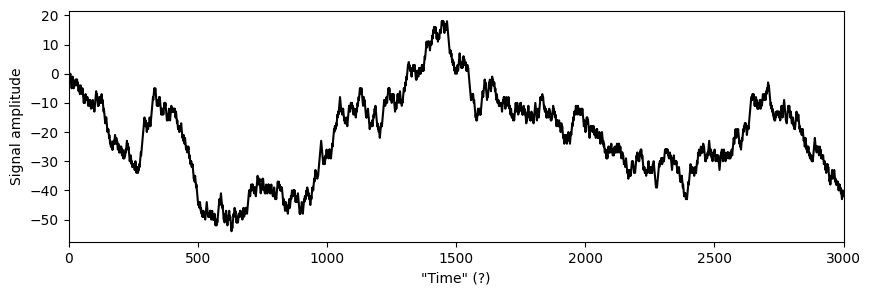

In [ ]:
brown_noise = np.cumsum(np.random.choice([-1,1],3000))
plt.figure(figsize = (10,3))
plt.plot(brown_noise, 'k')
plt.gca().set(xlim = [0, len(brown_noise)], xlabel = '"Time" (?)', ylabel = 'Signal amplitude')
plt.show()

In [ ]:
brown_noise = np.cumsum(np.random.choice([-1,1], 30))
print('Clean Brown noise:')
print('\t',brown_noise,'\n')

offset = np.random.choice(len(vocab), 1)
brownian_random_tokens = brown_noise + offset

# test with random token indices
print(f'Brownian random tokens with offset: \n\t{brownian_random_tokens}\n')
print(f'Decoded text: \n\t{decoder(brownian_random_tokens, idx_2_word)}')

Clean Brown noise:
	 [-1 -2 -3 -2 -3 -2 -3 -2 -3 -4 -3 -4 -5 -6 -5 -4 -5 -4 -5 -6 -7 -6 -5 -6
 -7 -8 -7 -6 -7 -6] 

Brownian random tokens with offset: 
	[3513 3512 3511 3512 3511 3512 3511 3512 3511 3510 3511 3510 3509 3508
 3509 3510 3509 3510 3509 3508 3507 3508 3509 3508 3507 3506 3507 3508
 3507 3508]

Decoded text: 
	shaken shake shafts shake shafts shake shafts shake shafts shafted shafts shafted shaft shadowy shaft shafted shaft shafted shaft shadowy shadows shadowy shaft shadowy shadows shadow shadows shadowy shadows shadowy


## Distribution of word lenghts

In [ ]:
# @title
import re
import requests
import numpy as np
import string

###############
### Get Text
###############
dir = 'https://www.gutenberg.org/files/35/35-0.txt'

book = requests.get(dir)
text = book.text


def clean_text(text):
  ###############
  ### Character Replace with Space
  ###############
  # remove all weird signs
  regexp = re.compile(
      '\s+'
  )
  text = regexp.sub(' ', text)
  # remove all signs that are not ASCII
  text = re.sub('[^\x00-\x7F]+', ' ', text)
  # remove all digits
  text = re.sub('\d+', '', text)
  # make it lower
  text = text.lower()

  return text

def into_words(text):
  ################
  ### Parsing
  ################
  # split on white space and punctuations
  puncts_re = f'[{string.punctuation}\s]+'
  words = re.split(puncts_re, text)
  # remove white space beofre and after
  words = [item.strip() for item in words if item.strip()]
  # remove items of lenght 1
  words = [item for item in words if len(item)>1]

  return words

def make_vocab(text):
  ################
  ### Vocab
  ################
  vocab = sorted(set(words))

  n_wrods = len(words)
  n_lex = len(vocab)

  return vocab

text = clean_text(text)
words = into_words(text)
vocab = make_vocab(words)

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-464083836.py:22: SyntaxWarning: invalid escape sequence '\s'
  '\s+'
/tmp/ipython-input-464083836.py:28: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+', '', text)
/tmp/ipython-input-464083836.py:39: SyntaxWarning: invalid escape sequence '\s'
  puncts_re = f'[{string.punctuation}\s]+'


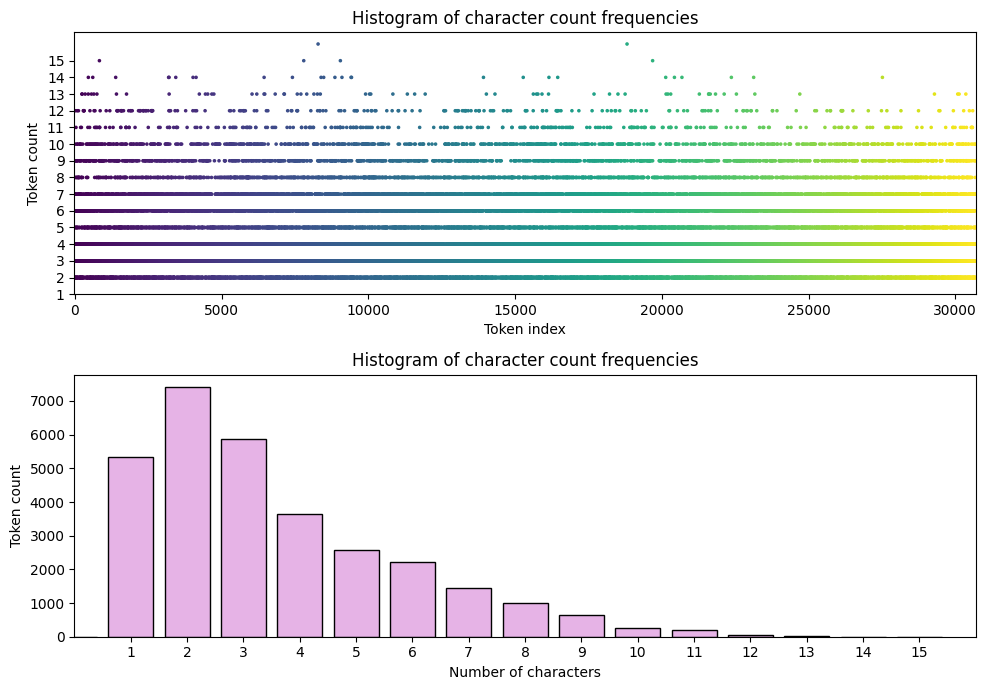

In [ ]:
n_words = len(words)

num_chars = np.zeros(n_words)
for i, w in enumerate(words):
  num_chars[i] = len(w)

# now count the number of words with those characters
char_counts = np.zeros(int(np.max(num_chars)))
for i in range(len(char_counts)):
  char_counts[i] = np.sum(num_chars==i+1)

# and plot
_, axs = plt.subplots(2,1,figsize = (10,7))
axs[0].scatter(range(n_words), num_chars, marker = '.', s = 10, c = np.linspace(.1, .9, len(num_chars)))
axs[0].set(yticks = range(1, int(np.max(num_chars))), xlabel = 'Token index', xlim = [-15, n_words],
           ylabel = 'Token count', title = 'Histogram of character count frequencies')

axs[1].bar(range(len(char_counts)), char_counts, edgecolor = 'k', color = [.9,.7,.9])
axs[1].set(xticks = range(1,len(char_counts)), xlim = [0, len(char_counts)], xlabel = 'Number of characters',
           ylabel = 'Token count', title = 'Histogram of character count frequencies')

plt.tight_layout()
plt.show()

## Encode a novel sentence

In [ ]:
sentence = 'The space aliens came to Earth to steal watermelons and staplers.'

# preprocess (remove punctuation, make lower-case, split into words)
words_new = re.split(f'[,.\s]+', sentence.lower())

# remove empty items
words_new = [item.strip() for item in words_new if item.strip()]
words_new

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-673647080.py:4: SyntaxWarning: invalid escape sequence '\s'
  words_new = re.split(f'[,.\s]+', sentence.lower())


['the',
 'space',
 'aliens',
 'came',
 'to',
 'earth',
 'to',
 'steal',
 'watermelons',
 'and',
 'staplers']

## Create a new encoder

In [ ]:
################
### Encoder / Decoder
################
word_2_idx_new = word_2_idx.copy()
idx_2_word_new = idx_2_word.copy()

# add an entry for unknown words
word_2_idx_new['<|unk|>'] = len(word_2_idx) + 1
idx_2_word_new[len(idx_2_word)+1] = '<|unk|>'

def encoder_new(text, enc_dict):
  idxs = np.zeros(len(text), dtype = int)

  for i,w in enumerate(text):
    if w in enc_dict:
      idxs[i] = enc_dict[w]
    else:
      idxs[i] = enc_dict['<|unk|>']

  return idxs

def decoder(idxs, dec_dict):
  return ' '.join(dec_dict[i] for i in idxs)

In [ ]:
idxs_new = encoder_new(words_new, word_2_idx_new)
idxs_new

array([4042, 3734, 4590,  519, 4119, 1191, 4119, 4590, 4590,  137, 4590])

In [ ]:
decoder(idxs_new, idx_2_word_new)

'the space <|unk|> came to earth to <|unk|> <|unk|> and <|unk|>'

# Byte-Pair Encoding Algorithm

* The mechanisms of BPE algorithm, which is widely used in real-world apps
* How the BPE algorithm (simplified version) is implemented in Python
* Additional steps used in professional tokenizers

### Motivation and theory

* Tokenization efficiency can be improved with tokens that represent longer character sequences (e.g., 'the' instead of ['t','h','e']).

* Character sequences that often appear together can be merged

* "Often appear together" is calculated empirically using large text datasets found online

* The basic algorithm is simple; the details get tricky for it to work at scale

* The key parameter is the vocab size, i.e. how many multi-character tokens to create

### BPE Algorithm

* step 0: Initialize a vocabulary comprising only characters (no pairs)
* step 1: loop through the text and count the frequency of sequential pairs
* step 2: find the most frequent pair and merge them to create a new token
* step 3: add that new token to the vocabulary
* step 4: loop through the text and replace the sequence with that new pair
* step 5: repeat steps 1-4 until the vocab contains k tokens

In [ ]:
import numpy

### Char Split

In [116]:
text = 'like liker love lovely hug hugs hugging hearts'
char = list(set(text))
char.sort()
for l in char:
  print(f'"{l}" is {text.count(l)} times in text')

" " is 7 times in text
"a" is 1 times in text
"e" is 5 times in text
"g" is 5 times in text
"h" is 4 times in text
"i" is 3 times in text
"k" is 2 times in text
"l" is 5 times in text
"n" is 1 times in text
"o" is 2 times in text
"r" is 2 times in text
"s" is 2 times in text
"t" is 1 times in text
"u" is 3 times in text
"v" is 2 times in text
"y" is 1 times in text


### String Text

Text needs to be in a list not in a string.

In [117]:
original_text = list(text)

print('       text: ', text)
print('string_text: ', original_text)

       text:  like liker love lovely hug hugs hugging hearts
string_text:  ['l', 'i', 'k', 'e', ' ', 'l', 'i', 'k', 'e', 'r', ' ', 'l', 'o', 'v', 'e', ' ', 'l', 'o', 'v', 'e', 'l', 'y', ' ', 'h', 'u', 'g', ' ', 'h', 'u', 'g', 's', ' ', 'h', 'u', 'g', 'g', 'i', 'n', 'g', ' ', 'h', 'e', 'a', 'r', 't', 's']


### Vocab

In [118]:
vocab = {tok:i for i,tok in enumerate(char)}
vocab

{' ': 0,
 'a': 1,
 'e': 2,
 'g': 3,
 'h': 4,
 'i': 5,
 'k': 6,
 'l': 7,
 'n': 8,
 'o': 9,
 'r': 10,
 's': 11,
 't': 12,
 'u': 13,
 'v': 14,
 'y': 15}

### Character Pairs

Find character pairs and merge the most frequent

In [119]:
token_pairs = dict()

for i in range(len(original_text) - 1):
  pair = original_text[i] + original_text[i+1]

  if pair in token_pairs:
    token_pairs[pair] += 1
  else:
    token_pairs[pair] = 1

token_pairs

{'li': 2,
 'ik': 2,
 'ke': 2,
 'e ': 2,
 ' l': 3,
 'er': 1,
 'r ': 1,
 'lo': 2,
 'ov': 2,
 've': 2,
 'el': 1,
 'ly': 1,
 'y ': 1,
 ' h': 4,
 'hu': 3,
 'ug': 3,
 'g ': 2,
 'gs': 1,
 's ': 1,
 'gg': 1,
 'gi': 1,
 'in': 1,
 'ng': 1,
 'he': 1,
 'ea': 1,
 'ar': 1,
 'rt': 1,
 'ts': 1}

### Most Frequent Pair

In [107]:
most_freq_pair_idx  = np.argmax(list(token_pairs.values()))
most_freq_pair_char = list(token_pairs.keys())[most_freq_pair_idx]
print(f'The most frequent character is "{most_freq_pair_char}" with {token_pairs[most_freq_pair_char]}')

The most frequent character is " h" with 4


### Update Vocab

In [115]:
vocab[most_freq_pair_char] = max(vocab.values()) + 1
vocab

{' ': 0,
 'a': 1,
 'e': 2,
 'g': 3,
 'h': 4,
 'i': 5,
 'k': 6,
 'l': 7,
 'n': 8,
 'o': 9,
 'r': 10,
 's': 11,
 't': 12,
 'u': 13,
 'v': 14,
 'y': 15,
 ' h': 16}

### New Text

In [137]:
new_text = []

i = 0
while i < (len(original_text)-1):
  if (original_text[i] + original_text[i+1]) == most_freq_pair_char:
    new_text.append(most_freq_pair_char)
    print(f'added: "{most_freq_pair_char}"')
    i += 2 # skip next char
  else:
    new_text.append(original_text[i])
    i += 1

print('\n')
print(f'Original text: {original_text}')
print(f'     New text: {new_text}')
print(f'\nOriginal text had {len(original_text)} tokens\n     New text has {len(new_text)} tokens')

added: " h"
added: " h"
added: " h"
added: " h"


Original text: ['l', 'i', 'k', 'e', ' ', 'l', 'i', 'k', 'e', 'r', ' ', 'l', 'o', 'v', 'e', ' ', 'l', 'o', 'v', 'e', 'l', 'y', ' ', 'h', 'u', 'g', ' ', 'h', 'u', 'g', 's', ' ', 'h', 'u', 'g', 'g', 'i', 'n', 'g', ' ', 'h', 'e', 'a', 'r', 't', 's']
     New text: ['l', 'i', 'k', 'e', ' ', 'l', 'i', 'k', 'e', 'r', ' ', 'l', 'o', 'v', 'e', ' ', 'l', 'o', 'v', 'e', 'l', 'y', ' h', 'u', 'g', ' h', 'u', 'g', 's', ' h', 'u', 'g', 'g', 'i', 'n', 'g', ' h', 'e', 'a', 'r', 't']

Original text had 46 tokens
     New text has 41 tokens


### Character Pairs (again)

In [145]:
token_pairs = dict()

for i in range(len(new_text)-1):
  pair = new_text[i] + new_text[i+1]

  if pair in token_pairs:
    token_pairs[pair] += 1
  else:
    token_pairs[pair] = 1

token_pairs

{'li': 2,
 'ik': 2,
 'ke': 2,
 'e ': 2,
 ' l': 3,
 'er': 1,
 'r ': 1,
 'lo': 2,
 'ov': 2,
 've': 2,
 'el': 1,
 'ly': 1,
 'y h': 1,
 ' hu': 3,
 'ug': 3,
 'g h': 2,
 'gs': 1,
 's h': 1,
 'gg': 1,
 'gi': 1,
 'in': 1,
 'ng': 1,
 ' he': 1,
 'ea': 1,
 'ar': 1,
 'rt': 1}

### Using Function

In [ ]:
def get_pair_stats(text_2_pair):
  token_pairs = dict()

  # loop over tokens
  for i in range(len(text_2_pair)-1):

    # create a pair
    pair = text_2_pair[i] + text_2_pair[i+1]

    # increase pair frequencies
    if pair in token_pairs:
      token_pairs[pair] += 1
    else:
      token_pairs[pair] = 1

  return token_pairs

In [ ]:
def update_vocab(token_pairs, vocab):

  # find the most frequent pair
  idx = np.argmax(list(token_pairs.values()))
  new_tok = list(token_pairs.keys())[idx]

  # update the vocab
  vocab[new_tok] = max(vocab.values()) + 1
  return vocab, new_tok

In [ ]:
def generate_new_token_seq(prev_text, new_token):

  # initialize a new text list
  new_text = []

  # loop through the list
  i = 0
  while i<(len(prev_text)-1):

    # test whether the pair of this and the following elements match the newly-created
    if (prev_text[i]+prev_text[i+1]) == new_token:
      new_text.append(new_token)
      i += 2 # skip the next character

    # not a pair
    else:
      new_text.append(prev_text[i])
      i += 1 # move to the next character

  return new_text

In [146]:
# re-initialize the vocab
vocab = {word:i for i, word in enumerate(char)}
print(f'Vocab has {len(vocab)} tokens.')

Vocab has 16 tokens.


In [147]:
# do one iteration

# find and count pairs
pairs = get_pair_stats(original_text)
# update the dictionary
vocab, new_token = update_vocab(pairs, vocab)
# get a new list of tokens
updated_text = generate_new_token_seq(orig_text, new_token)
print(f'Vocah has {len(vocab)} tokens')

Vocah has 17 tokens


In [148]:
# do second iteration

# find and count pairs
pairs = get_pair_stats(updated_text)
# update the dictionary
vocab, new_token = update_vocab(pairs, vocab)
# get a new list of tokens
updated_text = generate_new_token_seq(updated_text, new_token)
print(f'Vocab has {len(vocab)} tokens')

Vocab has 18 tokens


### Loop

In [174]:
def text_to_chars(text):
  chars = list(set(text))
  chars.sort()
  return chars

def chars_to_vocab(chars):
  vocab = {tok:i for i, tok in enumerate(chars)}
  return vocab

def get_pair_stats(text_2_pair):
  token_pairs = dict()

  # loop over tokens
  for i in range(len(text_2_pair)-1):

    # create a pair
    pair = text_2_pair[i] + text_2_pair[i+1]

    # increase pair frequencies
    if pair in token_pairs:
      token_pairs[pair] += 1
    else:
      token_pairs[pair] = 1

  return token_pairs

def update_vocab(token_pairs, vocab):

  # find the most frequent pair
  idx = np.argmax(list(token_pairs.values()))
  new_tok = list(token_pairs.keys())[idx]

  # update the vocab
  vocab[new_tok] = max(vocab.values()) + 1
  return vocab, new_tok

def generate_new_token_seq(prev_text, new_token):

  # initialize a new text list
  new_text = []

  # loop through the list
  i = 0
  while i<(len(prev_text)-1):

    # test whether the pair of this and the following elements match the newly-created
    if (prev_text[i]+prev_text[i+1]) == new_token:
      new_text.append(new_token)
      i += 2 # skip the next character

    # not a pair
    else:
      new_text.append(prev_text[i])
      i += 1 # move to the next character

  return new_text

In [198]:
def BPE_loop(text, vocab_size):
  chars = text_to_chars(text)
  vocab = chars_to_vocab(chars)

  while len(vocab) < vocab_size:
    pairs = get_pair_stats(text)
    vocab, new_token = update_vocab(pairs, vocab)
    text = generate_new_token_seq(text, new_token)

    print(f'Vocab has {len(vocab)} tokens after adding "{new_token}"')

  return vocab, text

In [199]:
text = 'like liker love lovely hug hugs hugging hearts'

In [201]:
vocab, text = BPE_loop(text = text, vocab_size = 25)

Vocab has 17 tokens after adding " h"
Vocab has 18 tokens after adding " l"
Vocab has 19 tokens after adding " hu"
Vocab has 20 tokens after adding " hug"
Vocab has 21 tokens after adding "ik"
Vocab has 22 tokens after adding "ike"
Vocab has 23 tokens after adding " lo"
Vocab has 24 tokens after adding " lov"
Vocab has 25 tokens after adding " love"


In [202]:
vocab

{' ': 0,
 'a': 1,
 'e': 2,
 'g': 3,
 'h': 4,
 'i': 5,
 'k': 6,
 'l': 7,
 'n': 8,
 'o': 9,
 'r': 10,
 's': 11,
 't': 12,
 'u': 13,
 'v': 14,
 'y': 15,
 ' h': 16,
 ' l': 17,
 ' hu': 18,
 ' hug': 19,
 'ik': 20,
 'ike': 21,
 ' lo': 22,
 ' lov': 23,
 ' love': 24}

In [203]:
text

['l',
 'ike',
 ' l',
 'ike',
 'r',
 ' love',
 ' love',
 'l',
 'y',
 ' hug',
 ' hug',
 's',
 ' hug',
 'g']